In [1]:
import numpy as np
import pandas as pd
from sklearn import datasets, ensemble
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.utils.fixes import parse_version
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
"""
Load the days, add two new columns given the timestamp, hours and days
"""
df = pd.read_excel("../../data/data_Hw3_new.xlsx")

df['timestamp'] = pd.to_datetime(df['timestamp'])

df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

feature_cols = ['A0', 'A1', 'A2', 'A3', 'temperature', 'humidity']
target_col = 'O3'

"""
Count the amount of hours in each of the days, remove any of them in case it does not have the 24 hours (none in our case)
"""
dates = df.groupby('date').size()
complete_dates = dates[dates == 24].index
print(dates[dates!= 24])
df = df[df['date'].isin(complete_dates)].copy()
df.head()

Series([], dtype: int64)


,timestamp,A0,A1,A2,A3,temperature,humidity,O3,date,hour
0,2023-06-04 00:00:00,455.58,451.83,449.58,445.33,21.47,69.58,54.0,2023-06-04,0
1,2023-06-04 01:00:00,452.92,452.75,448.75,446.25,21.17,71.98,64.0,2023-06-04,1
2,2023-06-04 02:00:00,453.50,452.58,444.92,447.00,21.03,71.65,56.0,2023-06-04,2
3,2023-06-04 03:00:00,450.75,452.25,437.58,446.50,21.10,70.75,43.0,2023-06-04,3
4,2023-06-04 04:00:00,448.58,451.50,433.33,445.50,20.79,69.68,34.0,2023-06-04,4


In [3]:
"""
Sort the days and divide them between train (80 days) and testing
"""
days = 80
testing_days = len(complete_dates) - days

hours = days*24
df = df.sort_values(by=["date", "hour"]).reset_index(drop=True)

train = df[:hours]
test = df[hours:]
train_x = train[feature_cols]
train_y = train[target_col]
test_x = test[feature_cols]
test_y = test[target_col]

In [4]:
"""
Train the best possible model using Gradient Boosting
"""
param_grid = {'max_depth': list(range(1, 15))}
gbr = ensemble.GradientBoostingRegressor(n_estimators = 500, min_samples_split = 5, learning_rate = 0.01, random_state=0)

grid = GridSearchCV(gbr, param_grid, cv=5, scoring='r2', n_jobs=-1, return_train_score=True)
grid.fit(train_x, train_y)

print("Best params:",)
print("Best CV r2:", grid.best_score_)

best_model_gb = grid.best_estimator_
# final evaluation on the untouched test set:
test_r2 = best_model_gb.score(test_x, test_y)
print("Test R2:", test_r2)

Best params:
Best CV r2: 0.7334105921326328
Test R2: 0.8529664096342782


In [5]:
"""
Train the best possible model using Random Forest
"""
param_grid = {'max_depth': list(range(1, 25))}
rfr = RandomForestRegressor(n_jobs=-1, random_state=0)

grid = GridSearchCV(rfr, param_grid, cv=5, scoring='r2', n_jobs=-1, return_train_score=True)
grid.fit(train_x, train_y)

print("Best params:",)
print("Best CV r2:", grid.best_score_)

best_model_rf = grid.best_estimator_
# final evaluation on the untouched test set:
test_r2 = best_model_rf.score(test_x, test_y)
print("Test R2:", test_r2)

Best params:
Best CV r2: 0.7074611958440717
Test R2: 0.8587757611751662


In [6]:
"""
Train the best possible model using Multiple Linear Regression
"""

best_model_mlr = LinearRegression().fit(train_x, train_y)


In [7]:
"""
Add the predicted data to the dataset
"""

df["predicted_gb"] = best_model_gb.predict(df[feature_cols])
df["predicted_rf"] = best_model_rf.predict(df[feature_cols])
df["predicted_mlr"] = best_model_mlr.predict(df[feature_cols])

# Update the views
train = df[:hours]
test = df[hours:]
train_x = train[feature_cols]
train_y = train[target_col]
test_x = test[feature_cols]
test_y = test[target_col]


# Expected shape: R(N, M), (24, 80)
L_gb = np.array(df.pivot(index='hour', columns='date', values=target_col).sort_index().values)
L_rf = np.array(df.pivot(index='hour', columns='date', values=target_col).sort_index().values)
L_mlr = np.array(df.pivot(index='hour', columns='date', values=target_col).sort_index().values)
if (L_gb.shape != L_rf.shape) or (L_gb.shape != L_mlr.shape):
    print("Error calculating L")
print("L shape:", L_mlr.shape)

# Expected shape: R(N, 1), (24, 1) 
Lambda_gb = L_gb.mean(axis=1, keepdims=True)
Lambda_rf = L_rf.mean(axis=1, keepdims=True)
Lambda_mlr = L_mlr.mean(axis=1, keepdims=True)
if (Lambda_gb.shape != Lambda_rf.shape) or (Lambda_gb.shape != Lambda_mlr.shape):
    print("Error calculating Lambda")
print("Lambda shape:", Lambda_mlr.shape)

# Expected shape: R(N, M), (24, 80)
X_gb = L_gb - Lambda_gb
X_rf = L_rf - Lambda_rf
X_mlr = L_mlr - Lambda_mlr
if (X_gb.shape != X_rf.shape) or (X_gb.shape != X_mlr.shape):
    print("Error calculating X")
print("X shape:", X_mlr.shape)

        
# Expected shape: 
# U: R(N, N), (24, 24)
# S: R(min(N, M)), (min(24, 80)), (24)
# Vt: R(M, M), (80, 80)
U_gb, S_gb, Vt_gb = np.linalg.svd(X_gb, full_matrices=True)
U_rf, S_rf, Vt_rf = np.linalg.svd(X_rf, full_matrices=True)
U_mlr, S_mlr, Vt_mlr = np.linalg.svd(X_mlr, full_matrices=True)
print("---SVD shape---")
print("U shape:", U_mlr.shape)
print("S shape:", S_mlr.shape)
print("Vt shape:", Vt_mlr.shape)

L shape: (24, 131)
Lambda shape: (24, 1)
X shape: (24, 131)
---SVD shape---
U shape: (24, 24)
S shape: (24,)
Vt shape: (131, 131)


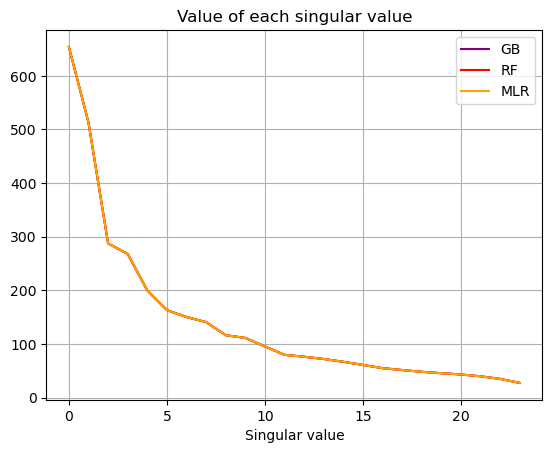

In [14]:
plt.figure()
plt.plot(range(len(S_gb)), S_gb, color='purple', label="GB")
plt.plot(range(len(S_rf)), S_rf, color='red', label="RF")
plt.plot(range(len(S_mlr)), S_mlr, color='orange',  label="MLR")
plt.xlabel("Singular value")
plt.ylabel("")
plt.title("Value of each singular value")
plt.legend()
plt.grid(True)
plt.savefig("images/singular_values_reference.png", dpi=300)
plt.show()

In [15]:
median_gb = np.median(S_gb)
median_rf= np.median(S_rf)
median_mlr = np.median(S_mlr)
beta =  len(Vt_gb)/len(U_gb)
sigma_gb = median_gb * (0.56 *(beta**3) - 0.95 * (beta**2) + 1.43 * beta)
sigma_rf = median_rf * (0.56 *(beta**3) - 0.95 * (beta**2) + 1.43 * beta)
sigma_mlr = median_mlr * (0.56 *(beta**3) - 0.95 * (beta**2) + 1.43 * beta)
optimal_gb_k = 0
optimal_rf_k = 0
optimal_mlr_k = 0
for i in range(len(S_gb)):
    if (S_gb[i] > sigma_gb):
        optimal_gb_k = optimal_gb_k + 1
    if (S_rf[i] > sigma_rf):
        optimal_rf_k = optimal_rf_k + 1
    if (S_mlr[i] > sigma_mlr):
        optimal_mlr_k = optimal_mlr_k + 1
print("Sigma for GB:", sigma_gb)
print("Sigma for RF:", sigma_rf)
print("Sigma for MLR:", sigma_mlr)
print("Optimal k for GB:", optimal_gb_k)
print("Optimal k for RF:", optimal_rf_k)
print("Optimal k for MLR:", optimal_mlr_k)

Sigma for GB: 18.177650253253155
Sigma for RF: 18.177650253253155
Sigma for MLR: 18.177650253253155
Optimal k for GB: 24
Optimal k for RF: 24
Optimal k for MLR: 24


In [10]:
"""
Find the best RMSE compared to the one obtained when not denoising
"""

RMSE_k_gb = []
R2_k_gb = []
RMSE_k_rf = []
R2_k_rf = []
RMSE_k_mlr = []
R2_k_mlr = []

# Matrice with the predicted values for the testing days
# Expected shape: R(N, test_days), R(24, 51)
M_test_gb = np.array(test['predicted_gb'].values.reshape(testing_days, 24)).T
M_test_rf = np.array(test['predicted_rf'].values.reshape(testing_days, 24)).T
M_test_mlr = np.array(test['predicted_mlr'].values.reshape(testing_days, 24)).T
print("M_test shape:", M_test_gb.shape)

# Real values
# Expected shape: R(test_days * 24), R(1224)
y_test = test[target_col]
print("Y_test shape:", y_test.shape)


for k in range(1, 25):
    # Expected shape: R(N, k), (24, k)
    U_r_gb = U_gb[:, :k]
    U_r_rf = U_rf[:, :k]
    U_r_mlr = U_mlr[:, :k]
    if U_r_gb.shape != (24, k) or U_r_rf.shape != (24, k) or U_r_mlr.shape != (24, k):
        print("Shape not correct")

    hat_x_gb = M_test_gb - Lambda_gb
    hat_x_rf = M_test_rf - Lambda_rf
    hat_x_mlr = M_test_mlr - Lambda_mlr
    M_denoised_gb = Lambda_gb + (U_r_gb @ (U_r_gb.T @ hat_x_gb))
    M_denoised_rf = Lambda_rf + (U_r_rf @ (U_r_rf.T @ hat_x_rf))
    M_denoised_mlr = Lambda_mlr + (U_r_mlr @ (U_r_mlr.T @ hat_x_mlr))
    y_denoised_gb = M_denoised_gb.flatten(order='f')
    y_denoised_rf = M_denoised_rf.flatten(order='f')
    y_denoised_mlr = M_denoised_mlr.flatten(order='f')

    RMSE_k_gb.append(np.sqrt(mean_squared_error(y_test, y_denoised_gb)))
    R2_k_gb.append(r2_score(y_test, y_denoised_gb))
    RMSE_k_rf.append(np.sqrt(mean_squared_error(y_test, y_denoised_rf)))
    R2_k_rf.append(r2_score(y_test, y_denoised_rf))
    RMSE_k_mlr.append(np.sqrt(mean_squared_error(y_test, y_denoised_mlr)))
    R2_k_mlr.append(r2_score(y_test, y_denoised_mlr))

print("-----GB-----")
print("Original RMSE:", RMSE_k_gb[-1], " Best RMSE:", min(RMSE_k_gb), "Index:" , np.argmin(RMSE_k_gb))
print("Original R2:", R2_k_gb[-1], " Best R2:", max(R2_k_gb), "Index:", np.argmax(R2_k_gb))
print("-----RF-----")
print("Original RMSE:", RMSE_k_rf[-1], " Best RMSE:", min(RMSE_k_rf), "Index:" , np.argmin(RMSE_k_rf))
print("Original R2:", R2_k_rf[-1], " Best R2:", max(R2_k_rf), "Index:", np.argmax(R2_k_rf))
print("-----MLR-----")
print("Original RMSE:", RMSE_k_mlr[-1], " Best RMSE:", min(RMSE_k_mlr), "Index:" , np.argmin(RMSE_k_mlr))
print("Original R2:", R2_k_mlr[-1], " Best R2:", max(R2_k_mlr), "Index:", np.argmax(R2_k_mlr))

M_test shape: (24, 51)
Y_test shape: (1224,)
-----GB-----
Original RMSE: 7.894792067829651  Best RMSE: 7.775633023418228 Index: 14
Original R2: 0.8529664096342782  Best R2: 0.8573713796804587 Index: 14
-----RF-----
Original RMSE: 7.737257244131787  Best RMSE: 7.64344190886881 Index: 20
Original R2: 0.8587757611751661  Best R2: 0.8621797261473838 Index: 20
-----MLR-----
Original RMSE: 9.808512101194466  Best RMSE: 9.799712706709718 Index: 22
Original R2: 0.7730441223276433  Best R2: 0.7734511521547672 Index: 22


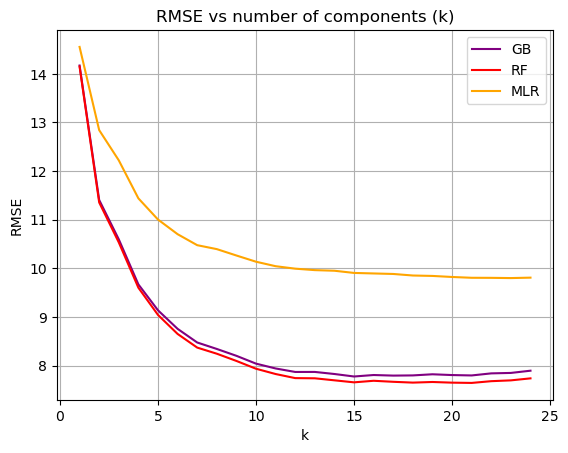

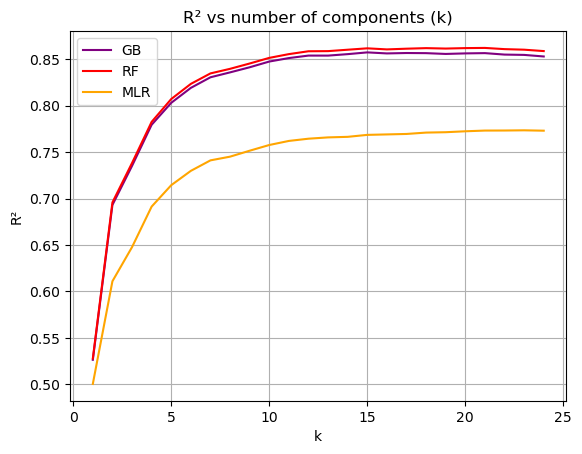

In [13]:
k_values = range(1, len(RMSE_k_gb) + 1)

# -------- RMSE plot --------
plt.figure()
plt.plot(k_values, RMSE_k_gb, color='purple', label="GB")
plt.plot(k_values, RMSE_k_rf, color='red', label="RF")
plt.plot(k_values, RMSE_k_mlr, color='orange', label="MLR")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("RMSE vs number of components (k)")
plt.legend()
plt.grid(True)
plt.savefig("images/denoising_LCS_RMSE_reference.png", dpi=300)
plt.show()

# -------- R² plot --------
plt.figure()
plt.plot(k_values, R2_k_gb, color='purple', label="GB")
plt.plot(k_values, R2_k_rf, color='red', label="RF")
plt.plot(k_values, R2_k_mlr, color='orange',  label="MLR")
plt.xlabel("k")
plt.ylabel("R²")
plt.title("R² vs number of components (k)")
plt.legend()
plt.grid(True)
plt.savefig("images/denoising_LCS_R2_reference.png", dpi=300)
plt.show()
